In [1]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2 -q

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 17.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
import torch
print(torch.cuda.is_available()) # Deve retornar True no Colab com GPU ativa

False


In [3]:
import pandas as pd
import numpy as np
import sys
import gc
import random
import os

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import sklearn

import time

# import tensorflow as tf
import tensorflow.compat.v2 as tf

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print("Scikit-Learn:", sklearn.__version__)
print("Tensorflow", tf.__version__)

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
Scikit-Learn: 1.5.2
Tensorflow 2.20.0


In [4]:
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Garante que as operações na GPU sejam determinísticas (pode reduzir sutilmente a performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tf.random.set_seed(SEED)

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [6]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [125]:
path = f'{path_main}/df_feat.csv'
df = get_data_frame(path)

In [126]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

In [127]:
df.shape, df.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [128]:
def print_nan(df):
    nan_count = df.isna().sum()
    # Filtra apenas onde a contagem é maior que zero
    nan_only = nan_count[nan_count > 0].sort_values(ascending=False)

    if nan_only.empty:
        print("Nenhum valor NaN encontrado!")
    else:
        print("Colunas com valores NaN:")
        print(nan_only)

In [129]:
def encode_categorical_columns(df):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols:
        print(f"Transformando a coluna: {col}")
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    return df_encoded

In [130]:
df = encode_categorical_columns(df)

Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade


In [131]:
# df = df.resample('W').sum()

# 1. Criamos um dicionário definindo a regra de agregação para cada coluna
regra_resample = {}

for col in df.columns:
    if col == 'total_casos':
        regra_resample[col] = 'sum'  # O alvo nós somamos na semana
    elif 'lag_' in col or 'mm' in col:
        regra_resample[col] = 'sum'  # Lags de casos também são somados
    else:
        regra_resample[col] = 'mean' # Temperatura, chuva e Fourier recebem a MÉDIA

# 2. Aplica o resample estratégico
df = df.resample('W').agg(regra_resample)

# 3. Remove quaisquer linhas com valores nulos resultantes do resample (se houver)
df = df.dropna()

In [132]:
print_nan(df)

Nenhum valor NaN encontrado!


In [133]:
df.head(20)

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2020-03-01,7.0,11.857143,27.000000,520.600000,24.200000,21.300000,92.427083,2020.0,3.000000,6.0,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
2020-03-08,61.0,11.707315,26.714930,11.942857,28.028571,19.085714,81.230655,2020.0,3.000000,3.0,...,0.000000e+00,-5.411949e-17,2.061843e-16,-2.318524e-16,0.611912,6.795975e-01,0.997039,0.068762,0.988186,0.136954
2020-03-15,40.0,11.876623,32.051525,0.428571,32.014286,20.585714,76.102679,2020.0,3.000000,3.0,...,8.723181e-16,-4.571662e-16,4.916702e-16,6.761630e-17,-0.611912,6.795975e-01,0.981544,0.188115,0.926940,0.368849
2020-03-22,25.0,11.702381,26.964286,3.214286,32.057143,21.871429,77.450893,2020.0,3.000000,3.0,...,8.723181e-16,3.927530e-16,-4.440892e-16,8.666853e-16,-0.739837,-5.375229e-01,0.951813,0.304741,0.812118,0.579424
2020-03-29,32.0,11.820068,36.823129,0.714286,29.657143,18.128571,75.264881,2020.0,3.000000,3.0,...,5.551115e-16,-7.081481e-16,-1.427430e-15,1.086852e-15,0.457244,-7.919703e-01,0.908279,0.416946,0.650355,0.756509
2020-04-05,30.0,11.780159,41.115079,3.142857,30.428571,19.785714,77.537202,2020.0,3.714286,3.0,...,5.392512e-16,6.493016e-16,6.026925e-16,2.734449e-15,0.835427,3.719560e-01,0.851573,0.523105,0.451001,0.889868
2020-04-12,26.0,11.621429,37.311905,12.628571,26.642857,19.314286,82.712798,2020.0,4.000000,3.0,...,-4.758099e-17,-3.923101e-17,2.918301e-15,-1.919569e-17,-0.282593,8.697303e-01,0.782516,0.621678,0.225580,0.971793
2020-04-19,28.0,11.724830,38.586054,2.514286,28.228571,18.885714,78.934524,2020.0,4.000000,3.0,...,-8.881784e-16,1.794029e-15,2.220446e-15,1.517379e-15,-0.894505,-1.901329e-01,0.702111,0.711235,-0.012880,0.997548
2020-04-26,31.0,11.795238,35.405294,0.285714,29.600000,17.257143,76.723214,2020.0,4.000000,3.0,...,1.538452e-15,1.200658e-15,2.172865e-15,5.559511e-16,0.095590,-9.094789e-01,0.611524,0.790477,-0.250595,0.965645


In [134]:
# lookback = 60
lookback = 8

### Train Test Split

In [135]:
# Separar o df
def train_test_split_by_date(
    data: pd.DataFrame | pd.Series,
    start_date: str,
    split_date: str,
    end_date: str | None = None,
):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data must have a DatetimeIndex")

    data = data.sort_index()
    start_date = pd.to_datetime(start_date)
    split_date = pd.to_datetime(split_date)
    end_date = pd.to_datetime(end_date) if end_date else data.index.max()

    if not (start_date < split_date < end_date):
        raise ValueError("start_date < split_date < end_date is required")

    start_pos = data.index.searchsorted(start_date, side="left")
    end_pos = data.index.searchsorted(end_date, side="right")
    data = data.iloc[start_pos:end_pos]

    split_pos = data.index.searchsorted(split_date, side="right")
    train = data.iloc[:split_pos]
    test = data.iloc[split_pos:]

    return train, test

In [136]:
start_date = df.index.min().strftime('%Y-%m-%d')
split_date_test = '2025-12-24' # 60 dias maior lag gerado
split_date_validation = '2025-08-26' # 60 dias
end_date = df.index.max().strftime('%Y-%m-%d')

start_date, split_date_validation, split_date_test, end_date

('2020-03-01', '2025-08-26', '2025-12-24', '2026-04-26')

In [137]:
df_train_temp, df_test = train_test_split_by_date(df, start_date, split_date_test, end_date)
df_train, df_val = train_test_split_by_date(df_train_temp, start_date, split_date_validation, split_date_test)

In [138]:
df_train.shape, df_train.index.unique()

((287, 66),
 DatetimeIndex(['2020-03-01', '2020-03-08', '2020-03-15', '2020-03-22',
                '2020-03-29', '2020-04-05', '2020-04-12', '2020-04-19',
                '2020-04-26', '2020-05-03',
                ...
                '2025-06-22', '2025-06-29', '2025-07-06', '2025-07-13',
                '2025-07-20', '2025-07-27', '2025-08-03', '2025-08-10',
                '2025-08-17', '2025-08-24'],
               dtype='datetime64[ns]', name='data', length=287, freq='W-SUN'))

In [139]:
df_val.shape, df_val.index.unique()

((17, 66),
 DatetimeIndex(['2025-08-31', '2025-09-07', '2025-09-14', '2025-09-21',
                '2025-09-28', '2025-10-05', '2025-10-12', '2025-10-19',
                '2025-10-26', '2025-11-02', '2025-11-09', '2025-11-16',
                '2025-11-23', '2025-11-30', '2025-12-07', '2025-12-14',
                '2025-12-21'],
               dtype='datetime64[ns]', name='data', freq='W-SUN'))

In [140]:
df_test.shape, df_test.index.unique()

((18, 66),
 DatetimeIndex(['2025-12-28', '2026-01-04', '2026-01-11', '2026-01-18',
                '2026-01-25', '2026-02-01', '2026-02-08', '2026-02-15',
                '2026-02-22', '2026-03-01', '2026-03-08', '2026-03-15',
                '2026-03-22', '2026-03-29', '2026-04-05', '2026-04-12',
                '2026-04-19', '2026-04-26'],
               dtype='datetime64[ns]', name='data', freq='W-SUN'))

In [141]:
print(f"Validação: {df_val.index.min()} até {df_val.index.max()} (Tamanho: {len(df_val)})")
print(f"Teste: {df_test.index.min()} até {df_test.index.max()} (Tamanho: {len(df_test)})")
print("Val e Test são iguais?", df_val.equals(df_test))

Validação: 2025-08-31 00:00:00 até 2025-12-21 00:00:00 (Tamanho: 17)
Teste: 2025-12-28 00:00:00 até 2026-04-26 00:00:00 (Tamanho: 18)
Val e Test são iguais? False


### Split

In [142]:
def split_target(df: pd.DataFrame, columns_target: str):
    y = df[columns_target]
    X = df.drop(columns=[columns_target])

    return X, y

In [143]:
column_target = 'total_casos'

In [144]:
# Removendo lags manuais repetitivos para deixar o LSTM fazer o trabalho dele
lags_para_manter = [c for c in df.columns if 'lag_60d' in c or 'mm60d' in c or 'fourier' in c.lower() or 'sin' in c.lower() or 'cos' in c.lower()]
lags_para_remover = [c for c in df.columns if ('lag_' in c or 'mm' in c) and c not in lags_para_manter]

columns_features = df.drop(columns=[column_target] + lags_para_remover).columns

In [145]:
# lookback = 60  # Janela temporal do LSTM

# Garante o formato DatetimeIndex em todas as partições
df_train.index = pd.to_datetime(df_train.index)
df_val.index = pd.to_datetime(df_val.index)
df_test.index = pd.to_datetime(df_test.index)

df_train = df_train.sort_index()
df_val = df_val.sort_index()
df_test = df_test.sort_index()

# --- Construção do Treino ---
X_train = df_train.loc[:, columns_features]
y_train = df_train.loc[:, column_target]

# --- Construção da Validação (Colagem perfeita do histórico do treino) ---
X_val_puro = df_val.loc[:, columns_features]
y_val_puro = df_val.loc[:, column_target]
historico_val_X = df_train.loc[:, columns_features].tail(lookback)

X_val = pd.concat([historico_val_X, X_val_puro])
y_val = y_val_puro

# --- Construção do Teste (Colagem perfeita do histórico da validação) ---
X_test_puro = df_test.loc[:, columns_features]
y_test_puro = df_test.loc[:, column_target]
historico_test_X = df_val.loc[:, columns_features].tail(lookback)

X_test = pd.concat([historico_test_X, X_test_puro])
y_test = y_test_puro

print("--- SHAPES ALINHADOS PARA O SCALER ---")
print(f"Treino X e Y: {X_train.shape} e {y_train.shape}")
print(f"Validação X e Y: {X_val.shape} e {y_val.shape}")
print(f"Teste X e Y: {X_test.shape} e {y_test.shape}\n")

--- SHAPES ALINHADOS PARA O SCALER ---
Treino X e Y: (287, 41) e (287,)
Validação X e Y: (25, 41) e (17,)
Teste X e Y: (26, 41) e (18,)



In [146]:
# print(X_train.shape, y_train.shape)
# print(X_val.shape, y_val.shape)
# X_test.shape, y_test.shape

In [147]:
y_train.isna().sum().sum(), y_val.isna().sum().sum(), y_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [148]:
X_train.index, X_val.index, X_test.index

(DatetimeIndex(['2020-03-01', '2020-03-08', '2020-03-15', '2020-03-22',
                '2020-03-29', '2020-04-05', '2020-04-12', '2020-04-19',
                '2020-04-26', '2020-05-03',
                ...
                '2025-06-22', '2025-06-29', '2025-07-06', '2025-07-13',
                '2025-07-20', '2025-07-27', '2025-08-03', '2025-08-10',
                '2025-08-17', '2025-08-24'],
               dtype='datetime64[ns]', name='data', length=287, freq='W-SUN'),
 DatetimeIndex(['2025-07-06', '2025-07-13', '2025-07-20', '2025-07-27',
                '2025-08-03', '2025-08-10', '2025-08-17', '2025-08-24',
                '2025-08-31', '2025-09-07', '2025-09-14', '2025-09-21',
                '2025-09-28', '2025-10-05', '2025-10-12', '2025-10-19',
                '2025-10-26', '2025-11-02', '2025-11-09', '2025-11-16',
                '2025-11-23', '2025-11-30', '2025-12-07', '2025-12-14',
                '2025-12-21'],
               dtype='datetime64[ns]', name='data', freq='W-S

# Scaler

In [149]:
X_train.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'chuva_acum_15d', 'chuva_acum_21d', 'chuva_acum_30d', 'chuva_acum_45d',
       'chuva_acum_50d', 'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm60d',
       'temp_min_lag_60d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day_year_start', 'day_year_end',
       'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k1',
       'ciclos_fourier_cos_p7_k2', 'ciclos_fourier_sin_p7_k2',
       'ciclos_fourier_cos_p7_k3', 'ciclos_fourier_sin_p7_k3',
       'ciclos_fourier_cos_p30_k1', 'ciclos_fourier_sin_p30_k1',
       'ciclos_fourier_cos_p365_k1', 'ciclos_fourier_sin_p365_k1',
       'ciclos_fourier_cos_p365_k2', 'ciclos_fourier_sin_p365_k2'],
      dtype='object')

In [150]:
# fourier = X_train.filter(like='ciclo')
# cols_fourier = fourier.columns.to_list()
# cols_fourier

In [151]:
# X_train_fourier = X_train[cols_fourier]
# X_val_fourier = X_val[cols_fourier]
# X_test_fourier = X_test[cols_fourier]
# X_test_fourier

In [152]:
# X_train_s = X_train.drop(columns=cols_fourier)
# X_val_s = X_val.drop(columns=cols_fourier)
# X_test_s = X_test.drop(columns=cols_fourier)

In [153]:
# X_train_s.info()

In [154]:
# def encode_categorical_columns(df):
#     df_encoded = df.copy()
#     cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

#     for col in cat_cols:
#         print(f"Transformando a coluna: {col}")
#         df_encoded[col] = df_encoded[col].astype('category').cat.codes

#     return df_encoded

In [155]:
# X_train_s = encode_categorical_columns(X_train)
# X_val_s = encode_categorical_columns(X_val)
# X_test_s = encode_categorical_columns(X_test)

In [156]:
scaler_x = StandardScaler()

In [157]:
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

In [158]:
X_train_scaled = pd.DataFrame(X_train_scaled,
                                 columns=X_train.columns,
                                 index=X_train.index)

X_val_scaled = pd.DataFrame(X_val_scaled,
                                 columns=X_val.columns,
                                 index=X_val.index)

X_test_scaled = pd.DataFrame(X_test_scaled,
                                 columns=X_test.columns,
                                 index=X_test.index)

In [159]:
X_train_scaled.shape, X_train.shape

((287, 41), (287, 41))

In [160]:
X_val_scaled.shape, X_val.shape

((25, 41), (25, 41))

In [161]:
X_test_scaled.shape, X_test.shape

((26, 41), (26, 41))

In [162]:
X_test_scaled.head()

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2025-11-02,-0.788743,-0.889874,-0.162805,-0.591781,0.045595,1.691234,1.607741,1.176365,-0.059131,-0.511882,...,-0.059131,-0.998753,-0.059131,-0.539326,1.378901,-0.298161,-0.700857,-1.319368,-0.735810,1.208359
2025-11-09,-0.166485,-0.029447,-0.030146,-0.222261,0.261126,0.493093,1.607741,1.393426,-0.059131,-0.283142,...,-0.059131,-0.094882,-0.059131,0.669712,0.434721,1.343442,-0.547696,-1.394011,-1.002823,0.997930
2025-11-16,-1.577661,-0.930967,-0.383339,-0.407021,-0.529153,-0.260286,1.607741,1.393426,-0.059131,-0.308653,...,-0.059131,-0.094622,-0.059131,3.288720,-1.290381,0.572448,-0.386708,-1.449627,-1.211936,0.729803
2025-11-23,-0.787904,-1.296016,-0.169564,0.440980,-0.015985,-0.585997,1.607741,1.393426,-0.059131,-0.474045,...,-0.059131,1.535761,-0.059131,-0.441752,-0.706846,-1.230336,-0.220230,-1.485408,-1.351061,0.419477
2025-11-30,-0.636496,0.340238,0.285868,0.090410,0.071253,0.360000,1.607741,1.393426,-0.059131,0.550981,...,-0.059131,0.308238,-0.059131,-0.319697,1.140249,-0.836227,-0.050675,-1.500836,-1.412157,0.084887


In [163]:
print_nan(X_train_scaled)
print_nan(X_val_scaled)
print_nan(X_test_scaled)

Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!


In [164]:
X_test_scaled.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'chuva_acum_15d', 'chuva_acum_21d', 'chuva_acum_30d', 'chuva_acum_45d',
       'chuva_acum_50d', 'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm60d',
       'temp_min_lag_60d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day_year_start', 'day_year_end',
       'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k1',
       'ciclos_fourier_cos_p7_k2', 'ciclos_fourier_sin_p7_k2',
       'ciclos_fourier_cos_p7_k3', 'ciclos_fourier_sin_p7_k3',
       'ciclos_fourier_cos_p30_k1', 'ciclos_fourier_sin_p30_k1',
       'ciclos_fourier_cos_p365_k1', 'ciclos_fourier_sin_p365_k1',
       'ciclos_fourier_cos_p365_k2', 'ciclos_fourier_sin_p365_k2'],
      dtype='object')

# Metrics/Results

In [165]:
df_result = pd.DataFrame()

In [166]:
def get_erros_metric(y_test, predict, time):
    # Criamos um NOVO dicionário aqui dentro, sem depender de variável global
    metrics = {
        'Start': y_test.index.min(),
        'End': y_test.index.max(),
        'MAE': mean_absolute_error(y_test, predict),
        'MSE': mean_squared_error(y_test, predict),
        'RMSE': np.sqrt(mean_squared_error(y_test, predict)),
        'R2': r2_score(y_test, predict),
        'Seconds': round(time, 6)
    }
    return metrics

In [167]:
def add_resultado(df_result: pd.DataFrame, forecast_method: str, method_metrics: dict) -> pd.DataFrame:
    # Se ainda não tem coluna 'Type', cria
    if "Type" not in df_result.columns:
        df_result = pd.DataFrame(columns=["Type"])

    mask = df_result["Type"] == forecast_method

    if mask.any():
        for key, value in method_metrics.items():
            df_result.loc[mask, key] = value
    else:
        new_row = {"Type": forecast_method}
        new_row.update(method_metrics)
        df_result = pd.concat([df_result, pd.DataFrame([new_row])], ignore_index=True)

    return df_result

# LSTM

In [168]:
model_name = 'LSTM'

In [169]:
# import tensorflow.compat.v2 as tf

In [170]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Conv1D, LSTM, LeakyReLU, GRU, Dense, Dropout,
                                     BatchNormalization, Bidirectional,
                                     Add, Attention, GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [171]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

In [172]:
# tf.keras.backend.clear_session()

In [173]:
#from sklearn.model_selection import TimeSeriesSplit

# def lstm_model(X_train_lstm):
#     # Entrada de dados
#     inputs = Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]))

#     # Camada de projeção inicial para enriquecer as features de entrada
#     init_projection = Dense(64, activation='gelu')(inputs)

#     # --- BLOCO RECORRENTE 1 ---
#     x1 = Bidirectional(LSTM(128, activation='tanh', return_sequences=True))(init_projection)
#     x1 = BatchNormalization()(x1)
#     x1 = Dropout(0.25)(x1)

#     # --- BLOCO RECORRENTE 2 ---
#     x2 = Bidirectional(GRU(64, activation='tanh', return_sequences=True))(x1)
#     x2 = BatchNormalization()(x2)
#     x2 = Dropout(0.25)(x2)

#     # --- BLOCO RECORRENTE 3 (Residual) ---
#     x3 = Bidirectional(LSTM(64, activation='tanh', return_sequences=True))(x2)
#     x3 = BatchNormalization()(x3)

#     # Conexão residual entre o bloco 2 e 3
#     res_1 = Add()([x2, x3])
#     res_1 = Dropout(0.3)(res_1)

#     # --- MECANISMO DE ATENÇÃO (O grande diferencial) ---
#     # O modelo aprende a dar pesos diferentes para momentos diferentes do passado
#     query = LSTM(128, activation='tanh', return_sequences=True)(res_1)
#     attn_output = Attention(dropout=0.2)([query, res_1])

#     # Concatenamos o contexto da atenção com a sequência original processada
#     context = Concatenate()([query, attn_output])

#     # --- REDUÇÃO TEMPORAL INTELIGENTE ---
#     # Em vez de pegar apenas o último estado, combinamos a compressão do LSTM com a média global
#     x4 = LSTM(64, activation='tanh', return_sequences=False)(context)
#     x4_pool = GlobalAveragePooling1D()(context)

#     # Fusão final das características temporais
#     merged = Concatenate()([x4, x4_pool])
#     merged = BatchNormalization()(merged)
#     merged = Dropout(0.3)(merged)

#     # --- CABEÇA DE REGRESSÃO DE ALTA CAPACIDADE ---
#     dense1 = Dense(64, activation='gelu')(merged)
#     dense1 = BatchNormalization()(dense1)
#     dense1 = Dropout(0.2)(dense1)

#     dense2 = Dense(16, activation='gelu')(dense1)
#     dense2 = BatchNormalization()(dense2)

#     outputs = Dense(1)(dense2)

#     # Construção do modelo
#     model = Model(inputs=inputs, outputs=outputs)

#     # --- OTIMIZAÇÃO AVANÇADA ---
#     # AMSGrad ajuda o Adam a convergir melhor em vales difíceis de perda
#     optimizer = Adam(learning_rate=0.001, amsgrad=True)
#     model.compile(optimizer=optimizer, loss=Huber(delta=1.3)) # Aumentado levemente o delta para dar foco a grandes tendências

#     return model

In [174]:
# def lstm_model(X_data):
#     inputs = Input(shape=(X_data.shape[1], X_data.shape[2]))

#     # Mantemos a sua estrutura que já provou melhora
#     x = LSTM(128, activation='tanh', return_sequences=True)(inputs)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)

#     x = LSTM(64, activation='tanh', return_sequences=False)(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)

#     x = Dense(32, activation='elu')(x)
#     x = Dense(16, activation='elu')(x)

#     outputs = Dense(1, activation='linear')(x)

#     model = Model(inputs=inputs, outputs=outputs)

#     # AJUSTE: Mudança para Huber Loss para mitigar o efeito de time-lag nos picos
#     model.compile(optimizer=Adam(learning_rate=0.0005), loss=Huber(delta=1.0))
#     return model

In [175]:
# Nunca use o mesmo objeto scaler que você usou para o X
scaler_y = StandardScaler()

In [176]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled  = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

In [177]:
X_train_scaled_np = X_train_scaled.values  # converte para NumPy array
X_val_scaled_np  = X_val_scaled.values
X_test_scaled_np  = X_test_scaled.values

In [178]:
# --- Remodelar para LSTM ---
# X_train_lstm = X_train_scaled_np.reshape((X_train_scaled_np.shape[0], 1, X_train_scaled_np.shape[1]))
# X_val_lstm  = X_val_scaled_np.reshape((X_val_scaled_np.shape[0], 1, X_val_scaled_np.shape[1]))
# X_test_lstm  = X_test_scaled_np.reshape((X_test_scaled_np.shape[0], 1, X_test_scaled_np.shape[1]))

In [179]:
from tensorflow.keras.utils import timeseries_dataset_from_array

In [180]:
# Uma alternativa manual simples se preferir manter formato numpy:
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    if len(X) > len(y):
        # Se X tem histórico extra no começo, a primeira janela válida termina exatamente em 'time_steps'
        for i in range(len(y)):
            Xs.append(X[i:(i + time_steps)])
            ys.append(y[i])
    else:
        for i in range(len(X) - time_steps):
            Xs.append(X[i:(i + time_steps)])
            ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

In [181]:
# Exemplo para criar sequências reais de 30 dias de histórico
# lookback = 30

In [182]:
X_train_lstm, y_train_scaled = create_sequences(X_train_scaled_np, y_train_scaled, lookback)
X_val_lstm, y_val_scaled = create_sequences(X_val_scaled_np, y_val_scaled, lookback)
X_test_lstm, y_test_scaled = create_sequences(X_test_scaled_np, y_test_scaled, lookback)

#### Model

In [183]:
# def lstm_model(X_data):
#     # Forçamos a limpeza da sessão aqui dentro
#     tf.keras.backend.clear_session()

#     inputs = Input(shape=(X_data.shape[1], X_data.shape[2]))

#     # Arquitetura idêntica ao seu primeiro modelo (o melhor até aqui)
#     x = LSTM(128, activation='tanh', return_sequences=True)(inputs)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)

#     x = LSTM(64, activation='tanh', return_sequences=False)(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.3)(x)

#     x = Dense(32, activation='elu')(x)
#     x = Dense(16, activation='elu')(x)

#     outputs = Dense(1, activation='linear')(x)

#     model = Model(inputs=inputs, outputs=outputs)

#     # AJUSTE 1: Reduzimos o delta para focar na estabilidade da tendência
#     model.compile(optimizer=Adam(learning_rate=0.0005), loss=Huber(delta=0.8))
#     return model

In [184]:
def lstm_model(X_data):
    tf.keras.backend.clear_session()

    inputs = Input(shape=(X_data.shape[1], X_data.shape[2]))

    # Camada 1: LSTM pura (sem Batch Normalization para não frear os picos)
    x = LSTM(128, activation='tanh', return_sequences=True)(inputs)
    x = Dropout(0.3)(x)

    # Camada 2: Segunda LSTM para consolidar a tendência
    x = LSTM(64, activation='tanh', return_sequences=False)(x)
    x = Dropout(0.3)(x)

    # Camadas Densas com LeakyReLU para permitir reações rápidas e agressivas
    x = Dense(32)(x)
    x = LeakyReLU(alpha=0.1)(x)

    x = Dense(16)(x)
    x = LeakyReLU(alpha=0.1)(x)

    # Saída linear pura
    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Voltamos para o MSE com taxa menor (0.0003) para forçar o modelo a caçar os picos
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='mse')
    return model

In [185]:
tf.keras.backend.clear_session()
model_lstm_val = lstm_model(X_train_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [186]:
early_stop = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)

In [187]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Reduz a taxa de aprendizado pela metade
    patience=20,      # Se por 5 épocas o erro não cair
    min_lr=1e-6,     # Limite mínimo
    verbose=1
)

In [188]:
callbacks = [early_stop, reduce_lr]

In [189]:
start_time = time.time()
batch_size=32
history = model_lstm_val.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=600,
    batch_size=batch_size, # Se o modelo for muito grande, tente aumentar para 64 para estabilizar o gradiente
    verbose=1,
    callbacks=callbacks
)
end_time = time.time()

Epoch 1/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 1.0036 - val_loss: 0.0540 - learning_rate: 3.0000e-04
Epoch 2/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9054 - val_loss: 0.0296 - learning_rate: 3.0000e-04
Epoch 3/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8052 - val_loss: 0.0273 - learning_rate: 3.0000e-04
Epoch 4/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7274 - val_loss: 0.0254 - learning_rate: 3.0000e-04
Epoch 5/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6233 - val_loss: 0.0282 - learning_rate: 3.0000e-04
Epoch 6/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5814 - val_loss: 0.0371 - learning_rate: 3.0000e-04
Epoch 7/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4779 - val_loss: 0.0325 - learning_rate: 3.0000e-04
Epoch 8/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3837 - val_loss: 0.0212 - learning_rate: 3.0000e-04
Epoch 9/600
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3089 - val_loss: 0.0154 - learning_rate: 3.0

In [190]:
y_pred_val_scaled = model_lstm_val.predict(X_val_lstm)
y_pred_val_lstm = scaler_y.inverse_transform(y_pred_val_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step


In [191]:
y_pred_val_lstm_ = pd.DataFrame(y_pred_val_lstm, columns=[column_target], index=y_val.index)

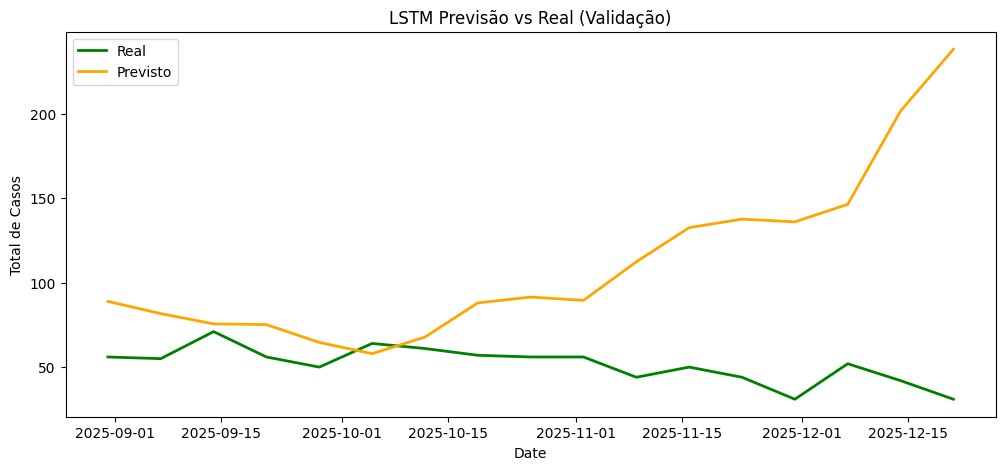

In [192]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_val_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Validação)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [193]:
metrics_ = dict()
metrics_ = get_erros_metric(y_val, y_pred_val_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-31,2025-12-21,60.054415,6722.868284,81.993099,-62.556066,26.882724


In [194]:
y_pred_test_scaled = model_lstm_val.predict(X_test_lstm)
y_pred_test_lstm = scaler_y.inverse_transform(y_pred_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step


In [195]:
y_pred_test_lstm_ = pd.DataFrame(y_pred_test_lstm, columns=[column_target], index=y_test.index)

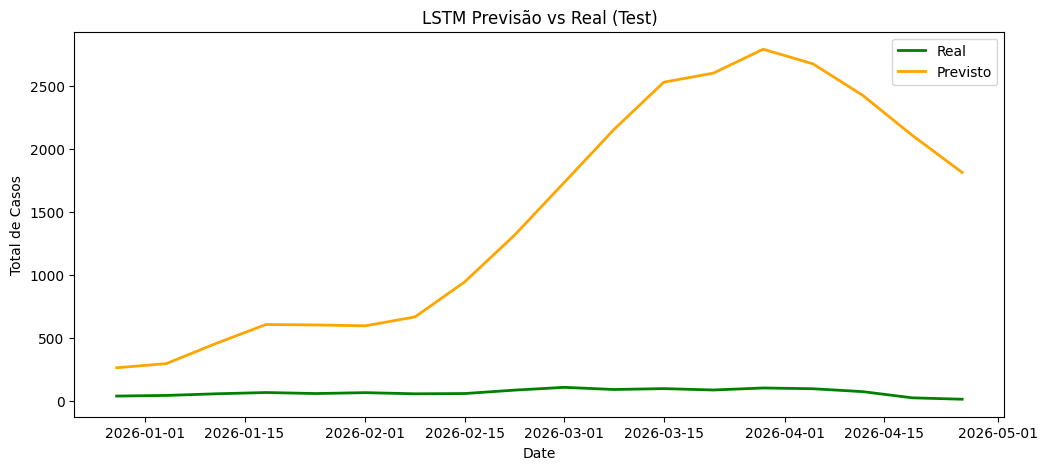

In [196]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [197]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-31,2025-12-21,60.054415,6.722868e+03,81.993099,-62.556066,26.882724
1,LSTM_test,2025-12-28,2026-04-26,1404.941461,2.759738e+06,1661.245772,-4003.689042,26.882724


In [ ]:
# Train + Val
# 1. Unir os dados de Treino e Validação (X e y já escalonados)
X_final_train = np.concatenate((X_train_lstm, X_val_lstm), axis=0)
y_final_train = np.concatenate((y_train_scaled, y_val_scaled), axis=0)

In [ ]:
best_epoch = np.argmin(history.history['val_loss']) + 1


# Ajuste do número de épocas (Fator de desconto)
# Se a melhor época foi 50, ele treinará por 40 para evitar o overfit no bloco Val
final_epochs = int(best_epoch * 0.8)

# Reduza as Épocas com um Fator de Desconto
# Treinar o número exato de best_epoch em um conjunto de dados maior quase sempre causa overfitting.
# Uma regra prática de Deep Learning para séries temporais é treinar entre 70% a 80% das épocas originais
# quando adicionamos a validação ao treino, ou aplicar uma taxa de aprendizado menor.

print(f"A melhor performance foi na época: {best_epoch}")
print(f"A melhor performance ajustada foi na época: {final_epochs}")

A melhor performance foi na época: 51
A melhor performance ajustada foi na época: 40


In [ ]:
# Re-treinar o modelo com o conjunto completo
model_lstm_agg = lstm_model(X_train_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
# Use o número de épocas que o Early Stopping encontrou anteriormente
start_time = time.time()
history = model_lstm_agg.fit(
    X_final_train, y_final_train,
    epochs=final_epochs, # Ou o melhor valor encontrado pelo early_stop
    batch_size=batch_size,
    verbose=1
    # Sem validation_data aqui, pois você uniu tudo para ganhar poder estatístico
)
end_time = time.time()

Epoch 1/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - loss: 0.8788
Epoch 2/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - loss: 0.6222
Epoch 3/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.5166
Epoch 4/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.4670
Epoch 5/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.4424
Epoch 6/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - loss: 0.4497
Epoch 7/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.4183
Epoch 8/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.4243
Epoch 9/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.4207
Epoch 10/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - loss: 0.4148
Epoch 11/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - loss: 0.4085
Epoch 12/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.3878
Epoch 13/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.3764
Epoch 14/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.3630
Epoch 15/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step 

In [ ]:
# Prever o Teste (O "mundo real" que o modelo nunca viu)
y_pred_test_scaled_final = model_lstm_agg.predict(X_test_lstm)
y_pred_test_final = scaler_y.inverse_transform(y_pred_test_scaled_final)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


In [ ]:
y_pred_test_final_ = pd.DataFrame(y_pred_test_final, columns=[column_target], index=y_test.index)

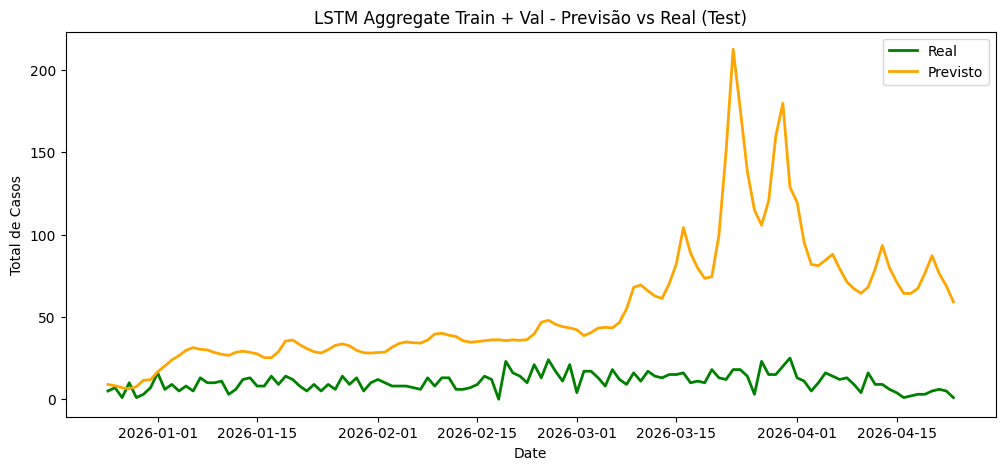

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_final_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_final_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.123515,61.401321,7.835900,-6.581450,931.124663
1,LSTM_test,2025-12-25,2026-04-23,100.977879,24142.007654,155.376986,-856.696337,931.124663
2,LSTM_test_agg,2025-12-25,2026-04-23,44.696833,3297.599816,57.424732,-116.154270,354.722244


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Recuperamos o Y de treino original inteiro e aplicamos o scaler nele
# Isso garante que ele tenha exatamente as mesmas 2005 linhas do X_train_scaled_np
y_train_puro_scaled = scaler_y.transform(y_train.values.reshape(-1, 1)).ravel()

# 2. Instancia o modelo XGBoost
model_xgb = XGBRegressor(
    n_estimators=300,       # Um pouco mais de árvores para capturar os picos
    learning_rate=0.03,
    max_depth=6,            # Profundidade boa para interações climáticas complexas
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Treina usando os dados pareados perfeitamente (2005 linhas em ambos)
model_xgb.fit(X_train_scaled_np, y_train_puro_scaled)

# 4. Alinha os alvos de Validação e Teste originais e inteiros
y_val_puro_scaled = scaler_y.transform(y_val_puro.values.reshape(-1, 1)).ravel()
y_test_puro_scaled = scaler_y.transform(y_test_puro.values.reshape(-1, 1)).ravel()

# Usamos os Xs originais que vêm logo após o scaler (sem o histórico colado do LSTM)
# O scaler_x gerou esses DataFrames antes, basta pegar os valores numpy deles:
X_val_original_np = X_val_scaled.loc[y_val_puro.index].values
X_test_original_np = X_test_scaled.loc[y_test_puro.index].values

# 5. Prediz na Validação e no Teste
y_pred_val_xgb_scaled = model_xgb.predict(X_val_original_np)
y_pred_test_xgb_scaled = model_xgb.predict(X_test_original_np)

# 6. Inverte a escala para voltar aos casos reais de dengue
y_pred_val_xgb = scaler_y.inverse_transform(y_pred_val_xgb_scaled.reshape(-1, 1))
y_pred_test_xgb = scaler_y.inverse_transform(y_pred_test_xgb_scaled.reshape(-1, 1))

# 7. Avalia os Resultados do Teste (Período Crítico do Verão)
mae_xgb_test = mean_absolute_error(y_test_puro, y_pred_test_xgb)
mse_xgb_test = mean_squared_error(y_test_puro, y_pred_test_xgb)
r2_xgb_test = r2_score(y_test_puro, y_pred_test_xgb)

# 8. Avalia os Resultados da Validação (Período Seco)
mae_xgb_val = mean_absolute_error(y_val_puro, y_pred_val_xgb)
r2_xgb_val = r2_score(y_val_puro, y_pred_val_xgb)

# Monta a tabela comparativa idêntica à sua
df_resultado_xgb = pd.DataFrame({
    'Type': ['XGBoost_val', 'XGBoost_test'],
    'Start': [y_val_puro.index.min().strftime('%Y-%m-%d'), y_test_puro.index.min().strftime('%Y-%m-%d')],
    'End': [y_val_puro.index.max().strftime('%Y-%m-%d'), y_test_puro.index.max().strftime('%Y-%m-%d')],
    'MAE': [mae_xgb_val, mae_xgb_test],
    'MSE': [mean_squared_error(y_val_puro, y_pred_val_xgb), mse_xgb_test],
    'RMSE': [np.sqrt(mean_squared_error(y_val_puro, y_pred_val_xgb)), np.sqrt(mse_xgb_test)],
    'R2': [r2_xgb_val, r2_xgb_test]
})

print("--- RESULTADO INTERPRETADO VIA GURUS DAS ÁRVORES (XGBOOST) ---")
display(df_resultado_xgb)

--- RESULTADO INTERPRETADO VIA GURUS DAS ÁRVORES (XGBOOST) ---


,Type,Start,End,MAE,MSE,RMSE,R2
0,XGBoost_val,2025-08-27,2025-12-24,3.482411,17.370813,4.167831,-1.144839
1,XGBoost_test,2025-12-25,2026-04-23,34.607726,1815.375610,42.607225,-63.495092


In [ ]:
# # Usando seus dados já devidamente escalados previamente
# X_completo = X_final_train
# y_completo = y_final_train

# tscv = TimeSeriesSplit(n_splits=50, max_train_size=None)
# # tscv = TimeSeriesSplit(n_splits=50, max_train_size=365)
# fold = 1
# fold_losses = []
# best_model = None
# importancias_acumuladas = []

# print("🚀 Iniciando Treino Temporal Inteligente...")

# for train_index, val_index in tscv.split(X_completo):
#     # Separação estrita baseada na linha do tempo
#     X_train_fold, X_val_fold = X_completo[train_index], X_completo[val_index]
#     y_train_fold, y_val_fold = y_completo[train_index], y_completo[val_index]

#     # Instancia um modelo zerado para este bloco temporal
#     model = lstm_model(X_train_fold)

#     # ATIVAÇÃO DOS CALLBACKS: Crucial para o modelo não estagnar/viciar
#     # callbacks = [
#     #     # Se parar de melhorar por 7 épocas, interrompe para não "decorar" a média
#     #     EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
#     #     # Se estagnar, reduz o learning rate para tentar achar padrões locais refinados
#     #     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
#     # ]

#     # Treina usando as variáveis puras (já escaladas por você antes)
#     model.fit(
#         X_train_fold, y_train_fold,
#         validation_data=(X_val_fold, y_val_fold),
#         epochs=500, # Reduzido ligeiramente o teto para evitar overfit severo
#         batch_size=32,
#         verbose=1, # Mude para 1 se quiser acompanhar se a perda (loss) está caindo de verdade
#         callbacks=callbacks
#     )

#     val_loss = model.evaluate(X_val_fold, y_val_fold, verbose=0)
#     fold_losses.append(val_loss)
#     print(f"Fold {fold} - Val Loss (Huber): {val_loss:.4f}")

#     # Captura o último fold (o modelo que viu o máximo de histórico possível)
#     if fold == tscv.n_splits:
#         model_lstm_roll = model

#     fold += 1

# print("\n--- 📊 FIM DA VALIDAÇÃO CRUZADA ---")
# print(f"Média do Huber Loss nos 5 períodos: {np.mean(fold_losses):.4f}")

🚀 Iniciando Treino Temporal Inteligente...
Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 729ms/step - loss: 0.5813 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6820 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5460 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5928 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5127 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4353 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 7/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3470
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.4339 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4264 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 9/500
3

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.4721 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3123 - val_loss: 0.0389 - learning_rate: 0.0010
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2138 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1416 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1058 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0850 - val_loss: 5.9350e-04 - learning_rate: 0.0010
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0615
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0610 - val_loss: 8.4543e-04 - learning_rate: 0.0010
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0488 - val_loss: 0.0014 - learning_rate:

In [ ]:
# y_pred_test_scaled_final = model_lstm_roll.predict(X_test_lstm)
# y_pred_test_roll = scaler_y.inverse_transform(y_pred_test_scaled_final)

1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 570ms/step


In [ ]:
# y_pred_test_final_rolling_window = pd.DataFrame(y_pred_test_roll, columns=[column_target], index=y_test.index)

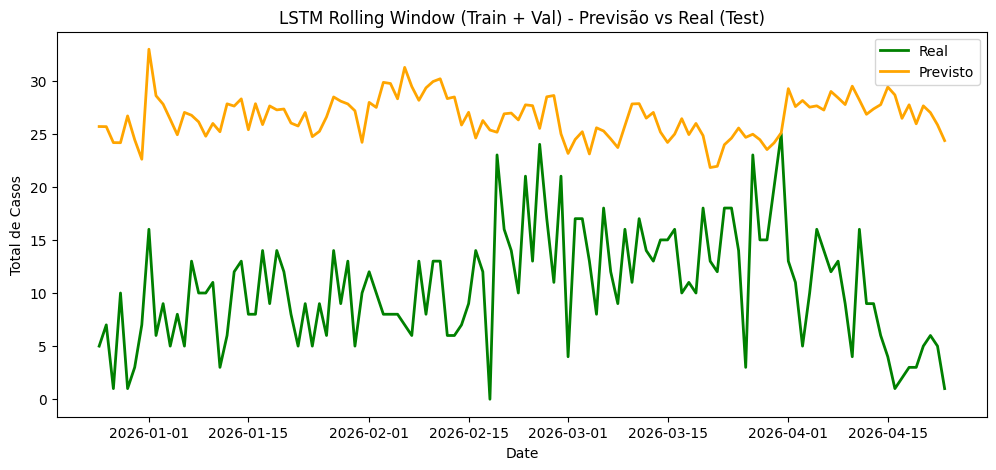

In [ ]:
# plt.figure(figsize=(12,5))
# plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
# plt.plot(y_test.index, y_pred_test_final_rolling_window, label='Previsto', color='orange', lw=2)
# plt.title(f"{model_name} Rolling Window (Train + Val) - Previsão vs Real (Test)")
# plt.xlabel("Date")
# plt.ylabel("Total de Casos")
# plt.legend()
# plt.show()

In [ ]:
# metrics_ = dict()
# metrics_ = get_erros_metric(y_test, y_pred_test_final_rolling_window, (end_time - start_time))
# df_result = add_resultado(df_result, f'{model_name}_test_rolling', metrics_)
# df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,LSTM_val,2025-08-27,2025-12-24,6.791340,75.001892,8.660363,-8.260763,86.121819
1,LSTM_test,2025-12-25,2026-04-23,9.783911,192.986719,13.891966,-5.856265,86.121819
2,LSTM_test_agg,2025-12-25,2026-04-23,20.394504,693.383725,26.332180,-23.633936,47.383656
3,LSTM_test_rolling,2025-12-25,2026-04-23,16.003438,290.410602,17.041438,-9.317456,47.383656


## SHAP

In [ ]:
import shap

In [ ]:
def interpretability_shap_lstm(model, X_train_model, X_test_model, train_n_lines=None, test_n_lines=None, nsamples=200, feature_names = X_train_scaled.columns.to_list()):
  # Usa pequena amostra para evitar lentidão
  if train_n_lines == None:
    train_n_lines = round(X_train_model.shape[0] / 3)
  if test_n_lines == None:
    test_n_lines = round(X_test_model.shape[0] / 3)

  X_background = X_train_model[:train_n_lines].reshape(train_n_lines, -1)
  X_test_sample = X_test_model[:test_n_lines].reshape(test_n_lines, -1)

  # Função de predição compatível (reconstrói o formato original esperado pelo modelo)
  def model_predict(x, model, X_train_model):
      # Reajusta o formato para (n_amostras, 1, n_features)
      x_reshaped = x.reshape(x.shape[0], 1, X_train_model.shape[2])
      return model.predict(x_reshaped)

  # Cria o KernelExplainer
  explainer = shap.KernelExplainer(lambda x: model_predict(x, model, X_train_model), X_background)

  # Calcula valores SHAP
  shap_values = explainer.shap_values(X_test_sample, nsamples=nsamples)

  # Flatten das X_test_model
  X_test_plot = X_test_model[:test_n_lines].reshape(test_n_lines, -1)
  shap_plot = shap_values.reshape(test_n_lines, -1)

  # Visualiza a importância média das features
  shap.summary_plot(shap_plot, X_test_plot, feature_names=feature_names)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4175/4175 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━

/tmp/ipykernel_4882/4207956614.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_plot, X_test_plot, feature_names=feature_names)


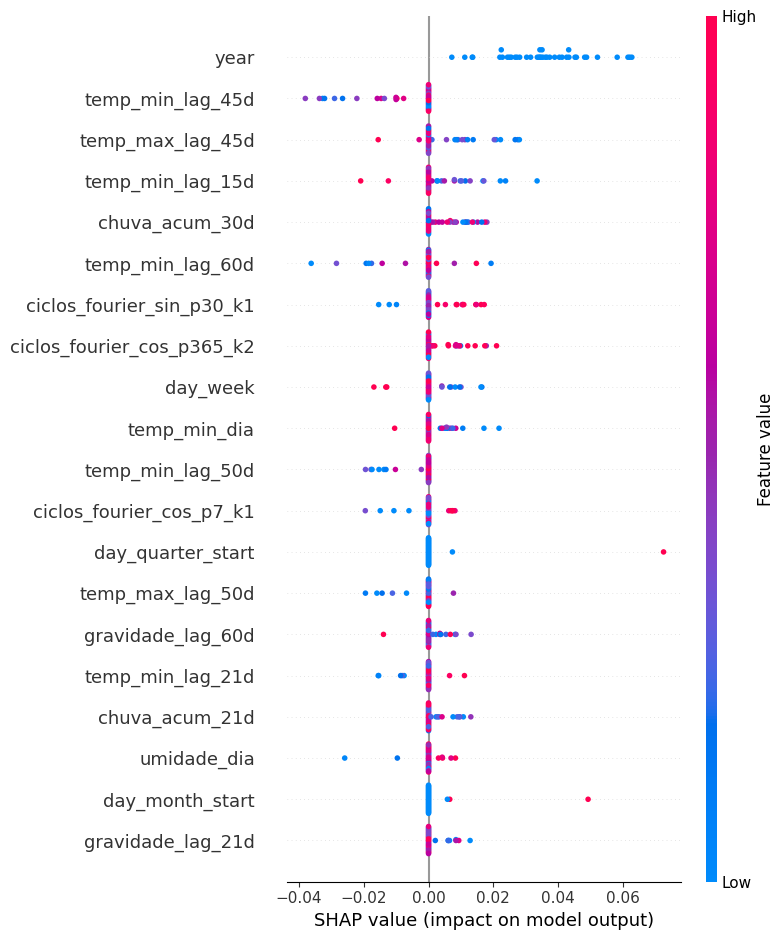

In [ ]:
# VAL
interpretability_shap_lstm(model_lstm_val, X_train_lstm, X_val_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━

/tmp/ipykernel_4882/4207956614.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_plot, X_test_plot, feature_names=feature_names)


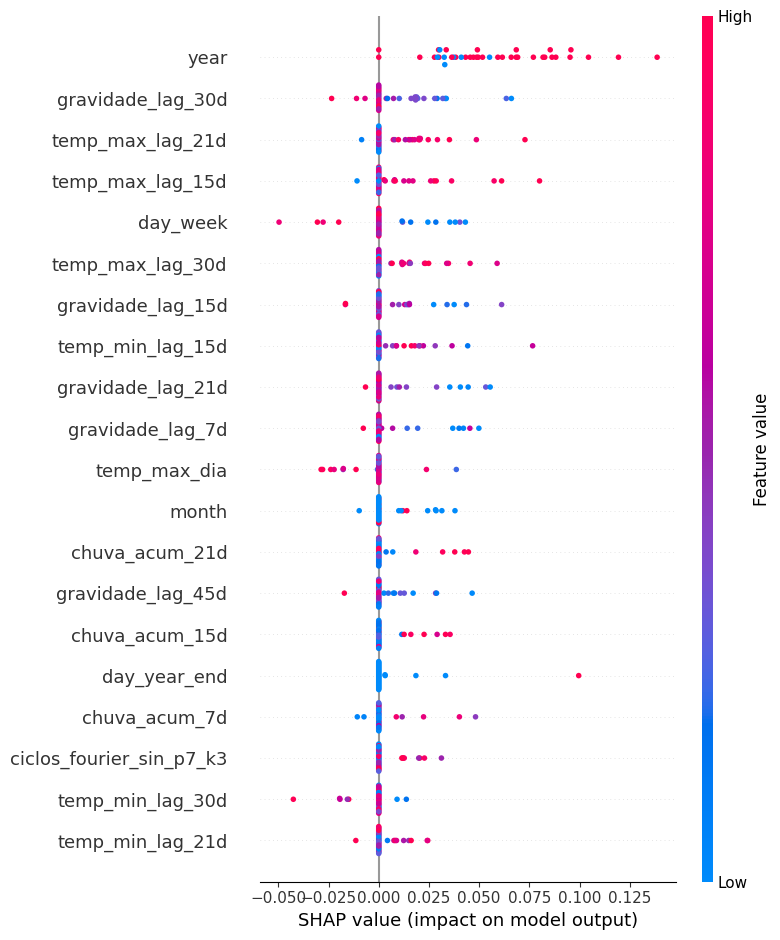

In [ ]:
# Test Agg
interpretability_shap_lstm(model_lstm_agg, X_final_train, X_test_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


  0%|          | 0/40 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
4425/4425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
1/1 ━━━━━━━━━━━━

/tmp/ipykernel_4882/4207956614.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_plot, X_test_plot, feature_names=feature_names)


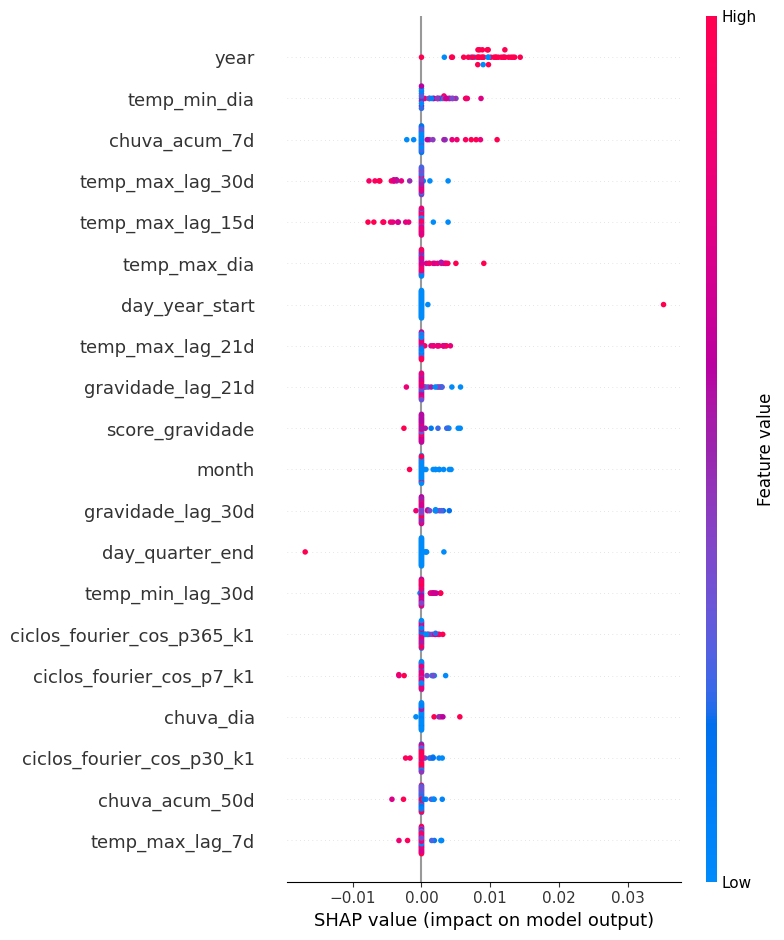

In [ ]:
# Test Rolling
interpretability_shap_lstm(model_lstm_roll, X_final_train, X_test_lstm, nsamples=200, feature_names = X_train_scaled.columns.to_list())